Dimensions de l'ensemble de données : (1000, 2)

Début du Clustering BIRCH (Construction du CF Tree et Regroupement)...
Nombre total de Clustering Features (sous-clusters) générés : 46
Quelques exemples de centroïdes de CF (LS/N) :
[[-6.59 -6.56]
 [ 4.86  2.3 ]
 [-2.68  8.35]]


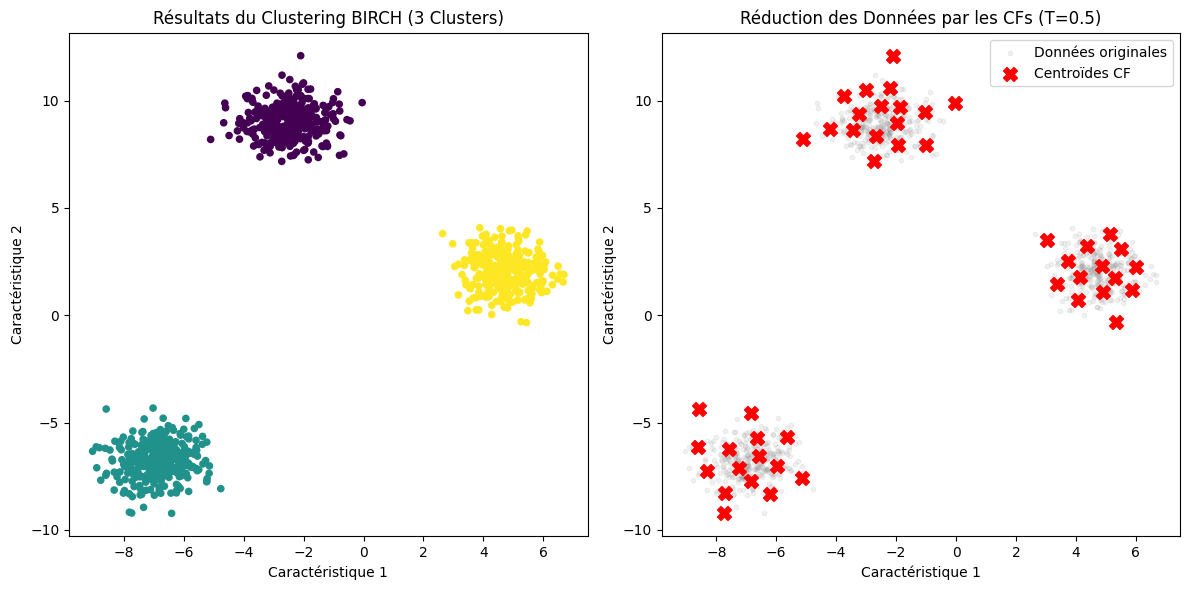

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import Birch
from sklearn.datasets import make_blobs

# --- 1. Préparation des Données de Démonstration ---
# Créer 1000 points de données (vecteurs 2D) avec 3 centres distincts.
# C'est l'ensemble de données "dans l'espace vectoriel euclidien".
X, y = make_blobs(n_samples=1000, centers=3, random_state=42, cluster_std=0.8)

print(f"Dimensions de l'ensemble de données : {X.shape}")

# --- 2. Définition et Application de l'Algorithme BIRCH ---
# BIRCH se déroule en trois phases dans cette implémentation :
# Phase 1: Construction du CF Tree.
# Phase 2: Réduction des CFs (si la mémoire est pleine).
# Phase 3: Regroupement des CFs terminaux avec un algorithme comme K-Means.

# Paramètres clés de BIRCH :
# threshold (T): Le diamètre maximal d'un sous-cluster dans un nœud feuille.
# n_clusters: Le nombre final de clusters à former (la phase 3).

# 🚨 IMPORTANT : Le 'threshold' (T) contrôle la finesse initiale du Clustering Feature Tree.
# Utiliser une valeur de T faible mène à plus de petits sous-clusters (CFs).
birch_model = Birch(
    threshold=0.5,  # Le diamètre maximal des sous-clusters CF (T)
    branching_factor=50, # Nombre maximum de sous-clusters dans un noeud (B)
    n_clusters=3        # Nombre de clusters finaux (K-Means sur les CFs)
)

print("\nDébut du Clustering BIRCH (Construction du CF Tree et Regroupement)...")
birch_model.fit(X)

# Obtenir les étiquettes de cluster prédites (résultat final du clustering hiérarchique)
labels = birch_model.predict(X)

# --- 3. Analyse des Clustering Features (CF) ---
# Les CFs sont la représentation (N, LS, SS) du cluster.
# On peut accéder aux centroïdes (LS/N) des sous-clusters générés dans la phase 1.

# Les centroïdes des sous-clusters finaux (avant la phase K-Means) sont stockés
cf_centroids = birch_model.subcluster_centers_
num_cf = cf_centroids.shape[0]

print(f"Nombre total de Clustering Features (sous-clusters) générés : {num_cf}")
print(f"Quelques exemples de centroïdes de CF (LS/N) :\n{np.round(cf_centroids[:3], 2)}")

# --- 4. Affichage des Résultats ---
plt.figure(figsize=(12, 6))

# Affichez les points de données colorés par leur cluster final
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=20, cmap='viridis')
plt.title(f"Résultats du Clustering BIRCH (3 Clusters)")
plt.xlabel("Caractéristique 1")
plt.ylabel("Caractéristique 2")

# Affichez les centroïdes des Clustering Features générés
plt.subplot(1, 2, 2)
# Les points sont les données originales, les croix sont les centroïdes des CF
plt.scatter(X[:, 0], X[:, 1], c='gray', alpha=0.1, s=10, label='Données originales')
plt.scatter(cf_centroids[:, 0], cf_centroids[:, 1], marker='X', s=100, color='red', label='Centroïdes CF')
plt.title(f"Réduction des Données par les CFs (T={birch_model.threshold})")
plt.xlabel("Caractéristique 1")
plt.ylabel("Caractéristique 2")
plt.legend()

plt.tight_layout()
plt.show()